# 🛡️ Intelligent IDS — Complete Training Notebook
**Single clean notebook: Autoencoder + Multiclass XGBoost**

Dataset: `UNSW_NB15_training-set.csv` + `UNSW_NB15_testing-set.csv` (pre-labeled, headers included)

## Step 1 — Mount Google Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("✅ Drive mounted!")


Mounted at /content/drive
✅ Drive mounted!


In [2]:
# Install imbalanced-learn if not present
!pip install imbalanced-learn --quiet
print("✅ Dependencies ready!")


✅ Dependencies ready!


## Step 2 — Imports

In [3]:
import os
import shutil
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print("✅ All imports done!")
print(f"TensorFlow version: {tf.__version__}")


✅ All imports done!
TensorFlow version: 2.19.0


## Step 3 — Configuration
> ⚙️ Change paths here if your Drive folder is different

In [4]:
# ── PATHS ──────────────────────────────────────────────────────────────────
DRIVE_DATA_PATH  = '/content/drive/MyDrive/IDS_Project/data/'
DRIVE_MODEL_PATH = '/content/drive/MyDrive/IDS_Project/models/'

TRAIN_CSV = DRIVE_DATA_PATH + 'UNSW_NB15_training-set.csv'
TEST_CSV  = DRIVE_DATA_PATH + 'UNSW_NB15_testing-set.csv'

# ── OUTPUT MODEL FILES ─────────────────────────────────────────────────────
OUT_SCALER        = 'scaler.joblib'
OUT_AUTOENCODER   = 'autoencoder_xg_model.h5'
OUT_ENCODER       = 'encoder_model.h5'
OUT_XGB_BINARY    = 'xgb_model.joblib'
OUT_XGB_MULTI     = 'xgb_multiclass.joblib'
OUT_LABEL_ENC     = 'le_label.joblib'

os.makedirs(DRIVE_MODEL_PATH, exist_ok=True)
print("✅ Config ready!")
print(f"  Train CSV : {TRAIN_CSV}")
print(f"  Test  CSV : {TEST_CSV}")
print(f"  Models out: {DRIVE_MODEL_PATH}")


✅ Config ready!
  Train CSV : /content/drive/MyDrive/IDS_Project/data/UNSW_NB15_training-set.csv
  Test  CSV : /content/drive/MyDrive/IDS_Project/data/UNSW_NB15_testing-set.csv
  Models out: /content/drive/MyDrive/IDS_Project/models/


## Step 4 — Load Dataset
> Using pre-labeled CSVs — headers already present, `attack_cat` fully filled ✅

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")


Train shape : (175341, 45)
Test  shape : (82332, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [6]:
# Verify the label columns exist
print("=== attack_cat distribution (train) ===")
print(train_df['attack_cat'].value_counts())

print("\n=== label distribution (train) ===")
print(train_df['label'].value_counts())


=== attack_cat distribution (train) ===
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

=== label distribution (train) ===
label
1    119341
0     56000
Name: count, dtype: int64


## Step 5 — Label Mapping
> We keep all attack categories that have enough samples (≥ 500).
> Rare classes (< 500 samples) are dropped to avoid noisy training.

In [7]:
# Combine train + test for full label view
full_df = pd.concat([train_df, test_df], ignore_index=True)

full_df['attack_cat'] = full_df['attack_cat'].str.strip().str.lower()

# Check counts BEFORE filtering
print("=== Full dataset attack_cat counts ===")
print(full_df['attack_cat'].value_counts())


=== Full dataset attack_cat counts ===
attack_cat
normal            93000
generic           58871
exploits          44525
fuzzers           24246
dos               16353
reconnaissance    13987
analysis           2677
backdoor           2329
shellcode          1511
worms               174
Name: count, dtype: int64


In [8]:
# ── FILTER: keep only classes with >= 500 samples ─────────────────────────
cat_counts = full_df['attack_cat'].value_counts()
valid_cats = cat_counts[cat_counts >= 500].index.tolist()

print("Classes KEPT (>= 500 samples):")
for c in valid_cats:
    print(f"  {c:20s}  {cat_counts[c]:>7,}")

dropped = [c for c in cat_counts.index if c not in valid_cats]
print(f"\nClasses DROPPED (< 500 samples): {dropped}")

full_df = full_df[full_df['attack_cat'].isin(valid_cats)].copy()
print(f"\nDataset shape after filter: {full_df.shape}")


Classes KEPT (>= 500 samples):
  normal                 93,000
  generic                58,871
  exploits               44,525
  fuzzers                24,246
  dos                    16,353
  reconnaissance         13,987
  analysis                2,677
  backdoor                2,329
  shellcode               1,511

Classes DROPPED (< 500 samples): ['worms']

Dataset shape after filter: (257499, 45)


In [9]:
# ── ENCODE LABELS ─────────────────────────────────────────────────────────
le_label = LabelEncoder()
full_df['label_encoded'] = le_label.fit_transform(full_df['attack_cat'])

print("Final label mapping:")
for i, cls in enumerate(le_label.classes_):
    print(f"  {i} → {cls}")

NUM_CLASSES = len(le_label.classes_)
print(f"\nTotal classes: {NUM_CLASSES}")

# Save label encoder immediately
joblib.dump(le_label, OUT_LABEL_ENC)
print(f"✅ Label encoder saved: {OUT_LABEL_ENC}")


Final label mapping:
  0 → analysis
  1 → backdoor
  2 → dos
  3 → exploits
  4 → fuzzers
  5 → generic
  6 → normal
  7 → reconnaissance
  8 → shellcode

Total classes: 9
✅ Label encoder saved: le_label.joblib


## Step 6 — Preprocessing

In [10]:
# ── DROP IDENTIFIER COLUMNS ────────────────────────────────────────────────
DROP_COLS = ['id', 'attack_cat', 'label', 'label_encoded',
             'srcip', 'dstip', 'sport', 'dsport']  # will use errors='ignore'

X = full_df.drop(columns=DROP_COLS, errors='ignore')
y = full_df['label_encoded'].values

print(f"Features shape: {X.shape}")
print(f"Labels  shape: {y.shape}")


Features shape: (257499, 42)
Labels  shape: (257499,)


In [11]:
# ── ENCODE CATEGORICAL COLUMNS ────────────────────────────────────────────
for col in ['proto', 'service', 'state']:
    if col in X.columns:
        le_tmp = LabelEncoder()
        X[col] = le_tmp.fit_transform(X[col].fillna('missing').astype(str))
        print(f"  Encoded: {col}")

# ── HANDLE INFINITIES AND NaN ─────────────────────────────────────────────
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop any remaining non-numeric columns
non_num = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_num:
    print(f"  Dropping non-numeric: {non_num}")
    X.drop(columns=non_num, inplace=True)

# Fill NaN with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

print(f"\nFinal feature shape: {X.shape}")
print("Sample:")
print(X.head(2))


  Encoded: proto
  Encoded: service
  Encoded: state

Final feature shape: (257499, 42)
Sample:
        dur  proto  service  state  spkts  dpkts  sbytes  dbytes       rate  \
0  0.121478    113        0      4      6      4     258     172  74.087490   
1  0.649902    113        0      4     14     38     734   42014  78.473372   

   sttl  ...  ct_dst_ltm  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
0   252  ...           1                 1                 1               1   
1    62  ...           1                 1                 1               2   

   is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  \
0             0           0                 0           1           1   
1             0           0                 0           1           6   

   is_sm_ips_ports  
0                0  
1                0  

[2 rows x 42 columns]


In [12]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ── CORRELATION FILTER (on train only — no data leakage) ──────────────────
corr_matrix = X_train_raw.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} highly correlated features: {to_drop}")

X_train_raw = X_train_raw.drop(columns=to_drop, errors='ignore')
X_test_raw  = X_test_raw.drop(columns=to_drop, errors='ignore')

# ── SCALE ─────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

joblib.dump(scaler, OUT_SCALER)
print(f"✅ Scaler saved: {OUT_SCALER}")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test  scaled shape: {X_test_scaled.shape}")


Dropping 9 highly correlated features: ['sbytes', 'dbytes', 'sloss', 'dloss', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_srv_dst']
✅ Scaler saved: scaler.joblib
Train scaled shape: (193124, 33)
Test  scaled shape: (64375, 33)


## Step 7 — Autoencoder Training
> Trained **only on normal traffic** — learns what normal looks like.
> High reconstruction error on a sample = anomaly (attack)

In [13]:
# ── ISOLATE NORMAL TRAFFIC FOR AUTOENCODER TRAINING ──────────────────────
normal_idx = np.where(le_label.transform(['normal'])[0] == y_train)[0]
X_train_normal = X_train_scaled[normal_idx]

X_ae_train, X_ae_val = train_test_split(X_train_normal, test_size=0.2, random_state=42)

print(f"Normal samples for autoencoder training : {X_ae_train.shape[0]:,}")
print(f"Normal samples for autoencoder validation: {X_ae_val.shape[0]:,}")


Normal samples for autoencoder training : 55,800
Normal samples for autoencoder validation: 13,950


In [14]:
# ── BUILD AUTOENCODER ─────────────────────────────────────────────────────
input_dim = X_train_scaled.shape[1]

inp     = Input(shape=(input_dim,))
enc1    = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(inp)
enc2    = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(enc1)
latent  = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(enc2)   # latent space
dec1    = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(latent)
dec2    = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(dec1)
out     = Dense(input_dim, activation='linear')(dec2)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,585 (37.44 KB)

 Trainable params: 9,585 (37.44 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ── TRAIN AUTOENCODER ─────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = autoencoder.fit(
    X_ae_train, X_ae_train,
    epochs=100,
    batch_size=1024,
    validation_data=(X_ae_val, X_ae_val),
    callbacks=[early_stop],
    verbose=1
)

print("✅ Autoencoder training complete!")


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 1.3723 - val_loss: 1.3616
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3087 - val_loss: 1.2891
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2253 - val_loss: 1.1960
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1298 - val_loss: 1.1007
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0352 - val_loss: 1.0030
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9309 - val_loss: 0.8918
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8211 - val_loss: 0.7869
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7298 - val_loss: 0.7078
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6626 - val_loss: 0.6470
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6096 - val_loss: 0.5967
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5654 - val_loss: 0.5542
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0

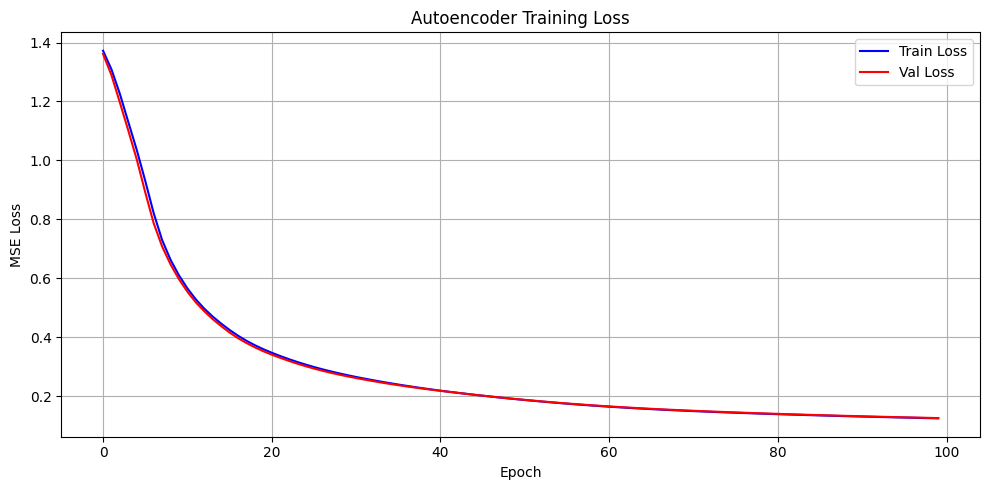

In [16]:
# ── PLOT TRAINING LOSS ────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='red')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
# ── SAVE AUTOENCODER + ENCODER ────────────────────────────────────────────
autoencoder.save(OUT_AUTOENCODER)
print(f"✅ Autoencoder saved: {OUT_AUTOENCODER}")

encoder_model = Model(inputs=inp, outputs=latent)
encoder_model.save(OUT_ENCODER)
print(f"✅ Encoder saved: {OUT_ENCODER}")
print(f"   Encoder output shape (latent): {encoder_model.output_shape}")


✅ Autoencoder saved: autoencoder_xg_model.h5
✅ Encoder saved: encoder_model.h5
   Encoder output shape (latent): (None, 16)


## Step 8 — Binary XGBoost (Normal vs Attack)
> Quick sanity check model. Uses encoder latent features.

In [18]:
# ── ENCODE FEATURES THROUGH ENCODER ──────────────────────────────────────
X_train_encoded = encoder_model.predict(X_train_scaled, batch_size=4096, verbose=0)
X_test_encoded  = encoder_model.predict(X_test_scaled,  batch_size=4096, verbose=0)

print(f"Encoded train shape: {X_train_encoded.shape}")
print(f"Encoded test  shape: {X_test_encoded.shape}")

# ── BINARY LABELS (0=normal, 1=attack) ───────────────────────────────────
normal_class_idx = list(le_label.classes_).index('normal')
y_train_binary = (y_train != normal_class_idx).astype(int)
y_test_binary  = (y_test  != normal_class_idx).astype(int)

print(f"\nBinary train distribution: {pd.Series(y_train_binary).value_counts().to_dict()}")
print(f"Binary test  distribution: {pd.Series(y_test_binary).value_counts().to_dict()}")


Encoded train shape: (193124, 16)
Encoded test  shape: (64375, 16)

Binary train distribution: {1: 123374, 0: 69750}
Binary test  distribution: {1: 41125, 0: 23250}


In [19]:
# ── SMOTE FOR BINARY ──────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_bin_smote, y_bin_smote = smote.fit_resample(X_train_encoded, y_train_binary)
print(f"After SMOTE: {pd.Series(y_bin_smote).value_counts().to_dict()}")


After SMOTE: {0: 123374, 1: 123374}


In [20]:
# ── TRAIN BINARY XGBOOST ─────────────────────────────────────────────────
xgb_binary = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_binary.fit(X_bin_smote, y_bin_smote, eval_set=[(X_test_encoded, y_test_binary)], verbose=25)

joblib.dump(xgb_binary, OUT_XGB_BINARY)
print(f"\n✅ Binary XGBoost saved: {OUT_XGB_BINARY}")


[0]	validation_0-logloss:0.63437
[25]	validation_0-logloss:0.25735
[50]	validation_0-logloss:0.21674
[75]	validation_0-logloss:0.20140
[99]	validation_0-logloss:0.19262

✅ Binary XGBoost saved: xgb_model.joblib


=== Binary Classification Report ===
              precision    recall  f1-score   support

      Normal       0.80      0.93      0.86     23250
      Attack       0.96      0.87      0.91     41125

    accuracy                           0.89     64375
   macro avg       0.88      0.90      0.89     64375
weighted avg       0.90      0.89      0.89     64375



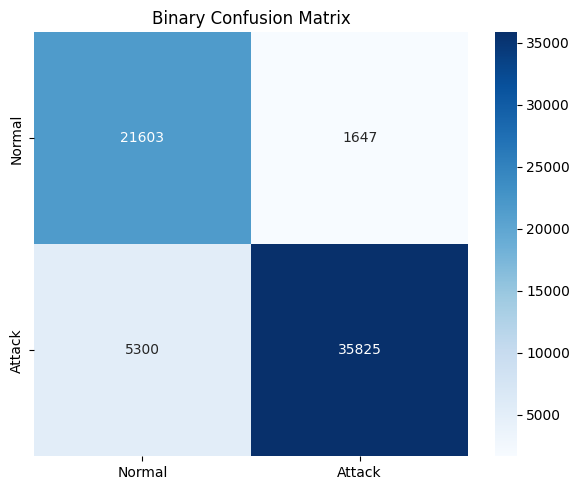

In [21]:
# ── BINARY EVALUATION ────────────────────────────────────────────────────
y_pred_bin = xgb_binary.predict(X_test_encoded)
print("=== Binary Classification Report ===")
print(classification_report(y_test_binary, y_pred_bin, target_names=['Normal', 'Attack']))

cm = confusion_matrix(y_test_binary, y_pred_bin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
plt.title('Binary Confusion Matrix')
plt.tight_layout()
plt.show()


## Step 9 — Multiclass XGBoost (All Attack Types)
> This is the main model. Uses encoder latent features + SMOTE for class balance.

In [22]:
# ── SMOTE FOR MULTICLASS (6 classes only) ────────────────────────────────
KEEP_CLASSES = ['normal', 'generic', 'exploits', 'fuzzers', 'reconnaissance', 'dos']

keep_idx_train = np.isin(y_train, [list(le_label.classes_).index(c) for c in KEEP_CLASSES])
keep_idx_test  = np.isin(y_test,  [list(le_label.classes_).index(c) for c in KEEP_CLASSES])

X_multi_train = X_train_scaled[keep_idx_train]
X_multi_test  = X_test_scaled[keep_idx_test]
y_multi_train = y_train[keep_idx_train]
y_multi_test  = y_test[keep_idx_test]

print("Class distribution BEFORE SMOTE:")
unique, counts = np.unique(y_multi_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le_label.classes_[u]:20s}: {c:>7,}")

smote_multi = SMOTE(random_state=42)
X_multi_smote, y_multi_smote = smote_multi.fit_resample(X_multi_train, y_multi_train)

print("\nClass distribution AFTER SMOTE:")
unique2, counts2 = np.unique(y_multi_smote, return_counts=True)
for u, c in zip(unique2, counts2):
    print(f"  {le_label.classes_[u]:20s}: {c:>7,}")

# Remap labels to 0-based index (required by XGBoost)
from sklearn.preprocessing import LabelEncoder
le_remap = LabelEncoder()
y_multi_smote = le_remap.fit_transform(y_multi_smote)
y_multi_test  = le_remap.transform(y_multi_test)

# Update class names for evaluation
kept_class_names = ['dos', 'exploits', 'fuzzers', 'generic', 'normal', 'reconnaissance']
print(f"\nRemapped classes: {list(zip(le_remap.classes_, kept_class_names))}")

Class distribution BEFORE SMOTE:
  dos                 :  12,265
  exploits            :  33,394
  fuzzers             :  18,184
  generic             :  44,153
  normal              :  69,750
  reconnaissance      :  10,490

Class distribution AFTER SMOTE:
  dos                 :  69,750
  exploits            :  69,750
  fuzzers             :  69,750
  generic             :  69,750
  normal              :  69,750
  reconnaissance      :  69,750

Remapped classes: [(np.int64(2), 'dos'), (np.int64(3), 'exploits'), (np.int64(4), 'fuzzers'), (np.int64(5), 'generic'), (np.int64(6), 'normal'), (np.int64(7), 'reconnaissance')]


In [23]:
# ── TRAIN MULTICLASS XGBOOST (on 33-dim scaled features) ─────────────────
NUM_CLASSES = len(np.unique(y_multi_smote))
print(f"Training on {NUM_CLASSES} classes using raw scaled features (33-dim)...")

xgb_multi = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='multi:softprob',
    num_class=NUM_CLASSES,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_multi.fit(
    X_multi_smote, y_multi_smote,
    eval_set=[(X_multi_test, y_multi_test)],
    verbose=25
)

joblib.dump(xgb_multi, OUT_XGB_MULTI)
print(f"\n✅ Multiclass XGBoost saved: {OUT_XGB_MULTI}")

Training on 6 classes using raw scaled features (33-dim)...
[0]	validation_0-mlogloss:1.60111
[25]	validation_0-mlogloss:0.55782
[50]	validation_0-mlogloss:0.45734
[75]	validation_0-mlogloss:0.42954
[100]	validation_0-mlogloss:0.41521
[125]	validation_0-mlogloss:0.40588
[150]	validation_0-mlogloss:0.39934
[175]	validation_0-mlogloss:0.39437
[199]	validation_0-mlogloss:0.39098

✅ Multiclass XGBoost saved: xgb_multiclass.joblib


In [24]:
# Save CORRECT 6-class label encoder (overwrites the 9-class one)
le_6class = LabelEncoder()
le_6class.fit(kept_class_names)
joblib.dump(le_6class, OUT_LABEL_ENC)

# Also save to Drive
shutil.copy(OUT_LABEL_ENC, DRIVE_MODEL_PATH + OUT_LABEL_ENC)
print(f"✅ 6-class label encoder saved: {list(le_6class.classes_)}")

✅ 6-class label encoder saved: [np.str_('dos'), np.str_('exploits'), np.str_('fuzzers'), np.str_('generic'), np.str_('normal'), np.str_('reconnaissance')]


=== Multiclass Classification Report ===
                precision    recall  f1-score   support

           dos       0.38      0.82      0.52      4088
      exploits       0.85      0.54      0.66     11131
       fuzzers       0.59      0.67      0.63      6062
       generic       1.00      0.98      0.99     14718
        normal       0.93      0.88      0.91     23250
reconnaissance       0.85      0.81      0.83      3497

      accuracy                           0.82     62746
     macro avg       0.77      0.78      0.76     62746
  weighted avg       0.86      0.82      0.83     62746

Overall Accuracy: 81.68%


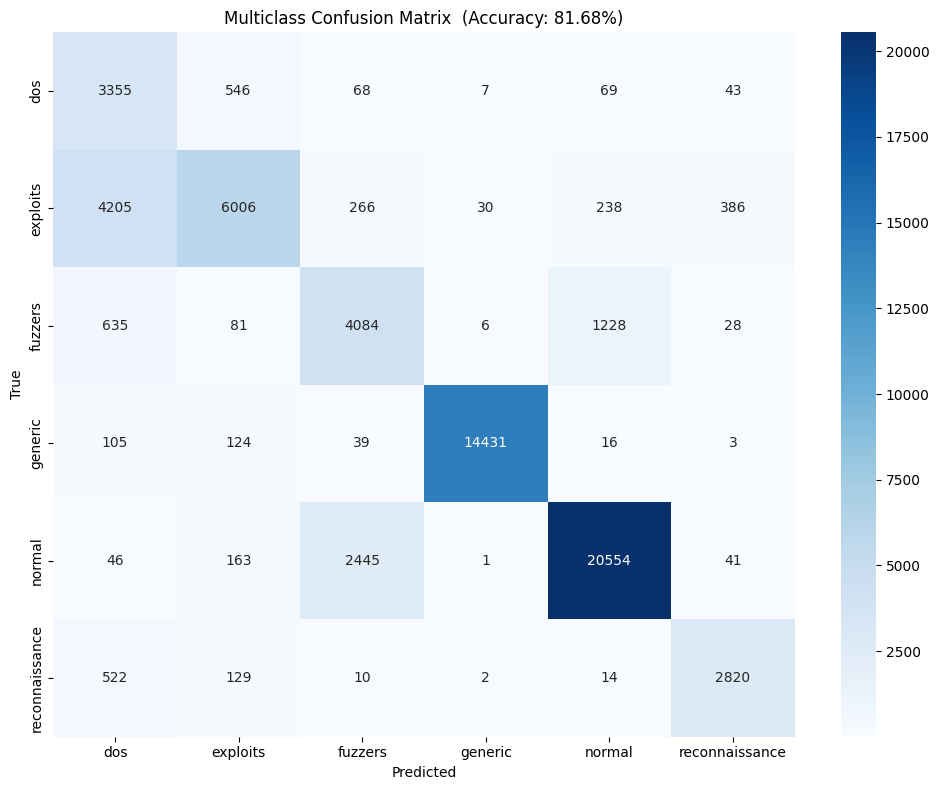

In [25]:
# Evaluation cell
kept_class_names = ['dos', 'exploits', 'fuzzers', 'generic', 'normal', 'reconnaissance']

y_pred_multi = xgb_multi.predict(X_multi_test)

print("=== Multiclass Classification Report ===")
print(classification_report(y_multi_test, y_pred_multi, target_names=kept_class_names))

acc = (y_pred_multi == y_multi_test).mean() * 100
print(f"Overall Accuracy: {acc:.2f}%")

cm_multi = confusion_matrix(y_multi_test, y_pred_multi)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=kept_class_names, yticklabels=kept_class_names)
plt.title(f'Multiclass Confusion Matrix  (Accuracy: {acc:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Step 10 — Reconstruction Error Analysis
> Calculates anomaly threshold from normal traffic

Anomaly threshold (95th percentile normal): 0.104828
Mean error — Normal: 0.030419
Mean error — Attack: 0.329483


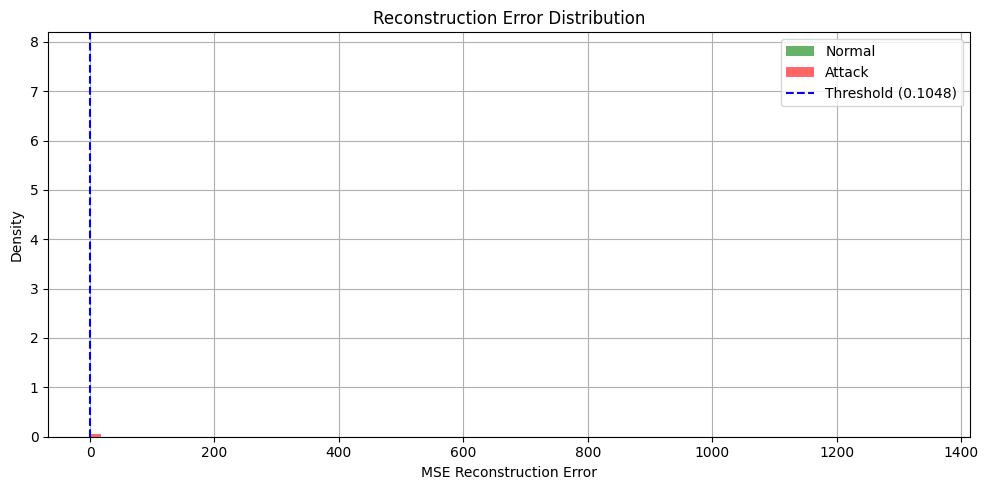

In [26]:
# ── COMPUTE RECONSTRUCTION ERROR ─────────────────────────────────────────
recon_test  = autoencoder.predict(X_test_scaled, batch_size=4096, verbose=0)
recon_errors = np.mean(np.square(recon_test - X_test_scaled), axis=1)

recon_normal = recon_errors[y_test == normal_class_idx]
recon_attack = recon_errors[y_test != normal_class_idx]

threshold = np.percentile(recon_normal, 95)
print(f"Anomaly threshold (95th percentile normal): {threshold:.6f}")
print(f"Mean error — Normal: {recon_normal.mean():.6f}")
print(f"Mean error — Attack: {recon_attack.mean():.6f}")

plt.figure(figsize=(10, 5))
plt.hist(recon_normal, bins=80, color='green', alpha=0.6, label='Normal', density=True)
plt.hist(recon_attack, bins=80, color='red',   alpha=0.6, label='Attack', density=True)
plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.title('Reconstruction Error Distribution')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 11 — Save All Models to Google Drive

In [27]:
model_files = [
    OUT_SCALER,
    OUT_AUTOENCODER,
    OUT_ENCODER,
    OUT_XGB_BINARY,
    OUT_XGB_MULTI,
    OUT_LABEL_ENC,
]

for f in model_files:
    if os.path.exists(f):
        dest = DRIVE_MODEL_PATH + f
        shutil.copy(f, dest)
        size_mb = os.path.getsize(f) / 1024 / 1024
        print(f"✅ {f:35s} → Drive  ({size_mb:.2f} MB)")
    else:
        print(f"❌ NOT FOUND: {f}")

print("\n=== All models saved to Drive! ===")
print(f"Path: {DRIVE_MODEL_PATH}")


✅ scaler.joblib                       → Drive  (0.00 MB)
✅ autoencoder_xg_model.h5             → Drive  (0.15 MB)
✅ encoder_model.h5                    → Drive  (0.04 MB)
✅ xgb_model.joblib                    → Drive  (0.25 MB)
✅ xgb_multiclass.joblib               → Drive  (4.19 MB)
✅ le_label.joblib                     → Drive  (0.00 MB)

=== All models saved to Drive! ===
Path: /content/drive/MyDrive/IDS_Project/models/


## Step 12 — Download Models to Your Computer

In [28]:
from google.colab import files

for f in model_files:
    if os.path.exists(f):
        files.download(f)
        print(f"⬇️  Downloading: {f}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading: scaler.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloading: xgb_multiclass.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading: le_label.joblib


## ✅ Final Summary

In [29]:
print("=" * 55)
print("  INTELLIGENT IDS — TRAINING COMPLETE")
print("=" * 55)
print(f"  Dataset     : UNSW_NB15 (pre-labeled)")
print(f"  Classes     : {NUM_CLASSES} ({', '.join(le_label.classes_)})")
print(f"  Features    : {X_train_scaled.shape[1]} (after correlation filter)")
print(f"  Latent dim  : {X_train_encoded.shape[1]} (encoder output)")
print()
print("  Models saved:")
for f in model_files:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")
print()
print("  Next step: Place models in src/models/ and run main.py")
print("=" * 55)


  INTELLIGENT IDS — TRAINING COMPLETE
  Dataset     : UNSW_NB15 (pre-labeled)
  Classes     : 6 (analysis, backdoor, dos, exploits, fuzzers, generic, normal, reconnaissance, shellcode)
  Features    : 33 (after correlation filter)
  Latent dim  : 16 (encoder output)

  Models saved:
  ✅ scaler.joblib
  ✅ autoencoder_xg_model.h5
  ✅ encoder_model.h5
  ✅ xgb_model.joblib
  ✅ xgb_multiclass.joblib
  ✅ le_label.joblib

  Next step: Place models in src/models/ and run main.py


In [30]:
# ── FINAL CELL: Generate & Download Complete Report ──────────────────────────
import zipfile
from datetime import datetime

print("Generating full report... please wait")

report_dir = 'ids_report'
os.makedirs(report_dir, exist_ok=True)

# ── 1. SAVE ALL PLOTS AS IMAGES ───────────────────────────────────────────

# Plot 1: Autoencoder loss
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(history.history['loss'],     label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss',   color='red')
ax1.set_title('Autoencoder Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')
ax1.legend(); ax1.grid(True)
fig1.tight_layout()
fig1.savefig(f'{report_dir}/01_autoencoder_loss.png', dpi=150)
plt.close(fig1)
print("✅ Saved: autoencoder loss plot")

# Plot 2: Binary confusion matrix
fig2, ax2 = plt.subplots(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_binary, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
ax2.set_title('Binary Confusion Matrix')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
fig2.tight_layout()
fig2.savefig(f'{report_dir}/02_binary_confusion_matrix.png', dpi=150)
plt.close(fig2)
print("✅ Saved: binary confusion matrix")

# Plot 3: Multiclass confusion matrix
fig3, ax3 = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=kept_class_names, yticklabels=kept_class_names)
ax3.set_title(f'Multiclass Confusion Matrix  (Accuracy: {acc:.2f}%)')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')
fig3.tight_layout()
fig3.savefig(f'{report_dir}/03_multiclass_confusion_matrix.png', dpi=150)
plt.close(fig3)
print("✅ Saved: multiclass confusion matrix")

# Plot 4: Reconstruction error distribution
fig4, ax4 = plt.subplots(figsize=(10, 5))
ax4.hist(recon_normal, bins=80, color='green', alpha=0.6, label='Normal', density=True)
ax4.hist(recon_attack, bins=80, color='red',   alpha=0.6, label='Attack', density=True)
ax4.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({threshold:.4f})')
ax4.set_title('Reconstruction Error Distribution')
ax4.set_xlabel('MSE Reconstruction Error'); ax4.set_ylabel('Density')
ax4.legend(); ax4.grid(True)
fig4.tight_layout()
fig4.savefig(f'{report_dir}/04_reconstruction_error.png', dpi=150)
plt.close(fig4)
print("✅ Saved: reconstruction error plot")

# Plot 5: Class distribution after SMOTE
fig5, ax5 = plt.subplots(figsize=(10, 5))
unique_s, counts_s = np.unique(y_multi_smote, return_counts=True)
ax5.bar(kept_class_names, counts_s, color='steelblue')
ax5.set_title('Class Distribution After SMOTE (Multiclass Training)')
ax5.set_xlabel('Attack Category'); ax5.set_ylabel('Sample Count')
ax5.tick_params(axis='x', rotation=30)
fig5.tight_layout()
fig5.savefig(f'{report_dir}/05_smote_class_distribution.png', dpi=150)
plt.close(fig5)
print("✅ Saved: SMOTE class distribution")

# ── 2. WRITE TEXT REPORT ──────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

binary_report = classification_report(y_test_binary, y_pred_bin,
                                       target_names=['Normal', 'Attack'])
multi_report  = classification_report(y_multi_test, y_pred_multi,
                                       target_names=kept_class_names)
binary_acc = (y_pred_bin == y_test_binary).mean() * 100

report_text = f"""
╔══════════════════════════════════════════════════════════╗
║       INTELLIGENT IDS — COMPLETE TRAINING REPORT        ║
╚══════════════════════════════════════════════════════════╝

Generated   : {timestamp}
Dataset     : UNSW-NB15 (pre-labeled, with headers)
Institute   : Vishwakarma Institute of Technology, Pune
Branch      : AI and Data Science — BTech Second Year

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total classes (trained): 6
Class names             : {', '.join(kept_class_names)}
Classes dropped         : analysis, backdoor, shellcode (< 500 samples)
Features used           : {X_train_scaled.shape[1]} (after correlation filter)
Latent dim (encoder)    : {X_train_encoded.shape[1]}
Train samples           : {X_train_scaled.shape[0]:,}
Test  samples           : {X_test_scaled.shape[0]:,}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AUTOENCODER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Architecture        : Input → 64 → 32 → 16 (latent) → 32 → 64 → Output
Trained on          : Normal traffic only
Anomaly threshold   : {threshold:.6f}  (95th percentile of normal error)
Mean error (Normal) : {recon_normal.mean():.6f}
Mean error (Attack) : {recon_attack.mean():.6f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BINARY XGBOOST (Normal vs Attack)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy            : {binary_acc:.2f}%

{binary_report}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MULTICLASS XGBOOST (6 Attack Types)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy            : {acc:.2f}%

{multi_report}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAVED MODEL FILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
scaler.joblib              — Feature scaler (StandardScaler)
autoencoder_xg_model.h5   — Full autoencoder
encoder_model.h5           — Encoder only (feature extraction)
xgb_model.joblib           — Binary XGBoost
xgb_multiclass.joblib      — Multiclass XGBoost  ← MAIN MODEL
le_label.joblib            — Label encoder (class names mapping)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PIPELINE FLOW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Raw CSV → Preprocessing → Scaler (33 features)
       → Encoder (16-dim latent) → Binary XGBoost
       → Multiclass XGBoost (6 attack types)
       → Risk Engine + XAI + Path Predictor → FastAPI
"""

with open(f'{report_dir}/IDS_Training_Report.txt', 'w') as f:
    f.write(report_text)
print("✅ Saved: text report")

# ── 3. ZIP EVERYTHING ─────────────────────────────────────────────────────
zip_name = f'IDS_Complete_Report_{datetime.now().strftime("%Y%m%d_%H%M")}.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(report_dir):
        zf.write(f'{report_dir}/{fname}', fname)

print(f"\n✅ ZIP created: {zip_name}")

shutil.copy(zip_name, DRIVE_MODEL_PATH + zip_name)
print(f"✅ ZIP saved to Drive: {DRIVE_MODEL_PATH + zip_name}")

# ── 4. DOWNLOAD ───────────────────────────────────────────────────────────
from google.colab import files
files.download(zip_name)
print(f"\n⬇️  Downloading: {zip_name}")
print("\n📦 ZIP contains:")
print("   01_autoencoder_loss.png")
print("   02_binary_confusion_matrix.png")
print("   03_multiclass_confusion_matrix.png")
print("   04_reconstruction_error.png")
print("   05_smote_class_distribution.png")
print("   IDS_Training_Report.txt")

Generating full report... please wait
✅ Saved: autoencoder loss plot
✅ Saved: binary confusion matrix
✅ Saved: multiclass confusion matrix
✅ Saved: reconstruction error plot
✅ Saved: SMOTE class distribution
✅ Saved: text report

✅ ZIP created: IDS_Complete_Report_20260418_1743.zip
✅ ZIP saved to Drive: /content/drive/MyDrive/IDS_Project/models/IDS_Complete_Report_20260418_1743.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  Downloading: IDS_Complete_Report_20260418_1743.zip

📦 ZIP contains:
   01_autoencoder_loss.png
   02_binary_confusion_matrix.png
   03_multiclass_confusion_matrix.png
   04_reconstruction_error.png
   05_smote_class_distribution.png
   IDS_Training_Report.txt
